# **Project Name**    - Uber Ride Demand-Supply Gap Analysis



# **Project Summary**

This project uses Exploratory Data Analysis (EDA) on Uber ride request data to find out when and why ride requests fail, helping improve driver availability, customer experience, and overall service efficiency.

In the fast-paced urban mobility market, demand often outpaces supply during peak hours, leading to cancelled rides and lost revenue. By analyzing when, where, and why Uber fails to complete ride requests, this project aims to support data-driven strategies that align driver availability with passenger demand.

**Data Collection and Preparation:**

The dataset includes key ride details like request time, pickup point, trip status, and trip duration. To prepare the data for analysis, missing values were handled, time formats were standardized, and new features such as request hour and day were extracted. Trip outcomes were also categorized to simplify analysis. These steps ensured the data was clean, consistent, and ready for meaningful insights.

**Key Insights**

* Severe No Supply issues occur during peak hours (7–9 AM and 5–9 PM), indicating a mismatch between rider demand and driver availability when service is needed most.
* Cancellations spike sharply on Friday mornings, suggesting operational gaps during end-of-week transitions, possibly due to driver fatigue or scheduling inefficiencies.
* Longer trip durations are concentrated in early mornings and late evenings, potentially driven by longer commutes or traffic-related delays during these periods.
* Weekday mornings and evenings show the highest rate of completed trips, reflecting strong, consistent commuter demand during typical office hours.
* Lack of clear clustering in trip behavior patterns indicates reactive driver deployment, highlighting an opportunity for more data-driven, proactive fleet management.

This analysis offers a clear view of Uber’s operational challenges and sets the stage for developing smarter driver allocation systems and forward-looking supply strategies.



# **GitHub Link**

Provide your GitHub Link here.

# **Problem Statement**



* Analyze the variation in ride fulfillment across time slots and weekdays to identify peak periods of supply-demand imbalance.
* Evaluate how ride request outcomes vary across pickup points to identify locations with frequent service disruptions.
* Analyze the relationship between driver availability and ride fulfillment, focusing on patterns of unassigned or incomplete trips.

#### **Business Objective**

The objective of this analysis is to explore ride request data to uncover when, where, and why Uber experiences service disruptions. By examining patterns across time slots, pickup locations, and driver availability, the goal is to identify the key factors contributing to unfulfilled trips. This will help inform strategies to improve ride fulfillment rates, reduce cancellations, and better align driver supply with customer demand.

## ***Know Your Data***

## Import Libraries

In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Dataset Loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
file_path = '/content/drive/My Drive/Uber_Dataset/Uber_Request_Data_Final_Cleaned.xlsx'
df = pd.read_excel(file_path)

## Data Sample

In [5]:
# Dataset First Look
df

,Request id,Pickup point,Driver id,Status,Request Timestamp,Drop Timestamp,Request Date,Request Hour,Drop Hour,Request Day,Trip Duration (Min),Trip_Status
0,619,Airport,1.0,Trip Completed,2016-07-11 11:51:00,2016-07-11 13:00:00,2016-07-11,11,13.0,Monday,69.000000,Completed
1,867,Airport,1.0,Trip Completed,2016-07-11 17:57:00,2016-07-11 18:47:00,2016-07-11,17,18.0,Monday,50.000000,Completed
2,1807,City,1.0,Trip Completed,2016-07-12 09:17:00,2016-07-12 09:58:00,2016-07-12,9,9.0,Tuesday,41.000000,Completed
3,2532,Airport,1.0,Trip Completed,2016-07-12 21:08:00,2016-07-12 22:03:00,2016-07-12,21,22.0,Tuesday,55.000000,Completed
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,2016-07-13,8,9.0,Wednesday,52.516667,Completed
...,...,...,...,...,...,...,...,...,...,...,...,...
6740,6745,City,NaN,No Cars Available,2016-07-15 23:49:03,NaT,2016-07-15,23,NaN,Friday,NaN,No Supply
6741,6752,Airport,NaN,No Cars Available,2016-07-15 23:50:05,NaT,2016-07-15,23,NaN,Friday,NaN,No Supply
6742,6751,City,NaN,No Cars Available,2016-07-15 23:52:06,NaT,2016-07-15,23,NaN,Friday,NaN,No Supply
6743,6754,City,NaN,No Cars Available,2016-07-15 23:54:39,NaT,2016-07-15,23,NaN,Friday,NaN,No Supply


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
rows, cols = df.shape
print(f"Number of Rows: {rows}")
print(f"Number of Columns: {cols}")

Number of Rows: 6745
Number of Columns: 12


### Dataset Information

In [7]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Request id           6745 non-null   int64         
 1   Pickup point         6745 non-null   object        
 2   Driver id            4095 non-null   float64       
 3   Status               6745 non-null   object        
 4   Request Timestamp    6745 non-null   datetime64[ns]
 5   Drop Timestamp       2831 non-null   datetime64[ns]
 6   Request Date         6745 non-null   datetime64[ns]
 7   Request Hour         6745 non-null   int64         
 8   Drop Hour            2831 non-null   float64       
 9   Request Day          6745 non-null   object        
 10  Trip Duration (Min)  2831 non-null   float64       
 11  Trip_Status          6745 non-null   object        
dtypes: datetime64[ns](3), float64(3), int64(2), object(4)
memory usage: 632.5+ KB


In [8]:
## Checking uniques values
unique_counts = df.nunique().sort_values(ascending=False)
print(unique_counts)

# nunique() ➔ Shows count of unique values. Good for a quick sense of variety in the column.

Request id             6745
Request Timestamp      5618
Drop Timestamp         2598
Trip Duration (Min)    1667
Driver id               300
Request Hour             24
Drop Hour                24
Request Date              5
Request Day               5
Status                    3
Trip_Status               3
Pickup point              2
dtype: int64


## Dataset at a Glance

**Uber Ride Request Data**

This dataset captures ride requests made on the Uber platform over a short period, primarily focusing on supply-demand gaps during different time slots and locations. Each row represents a single ride request and its associated information like timestamps, status, pickup point, and driver assignment.

---

**Columns Description**

**From Uber Ride Requests (Excel File):**

- **`Request id`** – Unique identifier for each ride request.
- **`Request timestamp`** – Time when the customer placed the request.
- **`Drop timestamp`** – Time when the trip was completed (if applicable).
- **`Pickup point`** – The pickup location of the ride: either **City** or **Airport**.
- **`Driver id`** – Identifier of the driver assigned to the ride (if assigned).
- **`Status`** – Final outcome of the ride: `Completed`, `Cancelled`, or `No Cars Available`.
- **`Request Hour`** – Extracted hour from the request timestamp (0–23), helpful in time-based analysis.
- **`Drop Hour`** – Extracted hour from the drop timestamp.
- **`Request Day`** – Day of the week the request was made (e.g., Monday, Tuesday).
- **`Trip Duration (Min)`** – Total duration of completed trips in minutes.
- **`Trip Status`** – Shows whether a ride was Completed, Cancelled, or failed due to No Supply (No Cars Available).

## ***Data Wrangling***

In [9]:
# Checking For null values
df.isnull().sum()

,0
Request id,0
Pickup point,0
Driver id,2650
Status,0
Request Timestamp,0
Drop Timestamp,3914
Request Date,0
Request Hour,0
Drop Hour,3914
Request Day,0




*   Missing values in columns like 'Driver id', 'Drop Timestamp', and 'Drop Hour' are replaced with 'Not Available' instead of dropping or imputing them.
*    These blanks represent real-world service gaps (e.g., unassigned trips or cancellations), which are crucial for analyzing supply-demand mismatches in the Uber system.

*   Preserving them allows accurate identification of patterns in service disruptions.

In [10]:
# Replacing missing values in key columns with 'Not Available' for better readability and cleaner analysis
df['Driver id'] = df['Driver id'].fillna('Not Available')
df['Drop Timestamp'] = df['Drop Timestamp'].fillna('Not Available')
df['Drop Hour'] = df['Drop Hour'].fillna('Not Available')

In [11]:
# Data Type Conversion
df['Request Hour'] = df['Request Hour'].astype(float)

In [12]:
# Checking Data type again for confirmation
df.dtypes

,0
Request id,int64
Pickup point,object
Driver id,object
Status,object
Request Timestamp,datetime64[ns]
Drop Timestamp,object
Request Date,datetime64[ns]
Request Hour,float64
Drop Hour,object
Request Day,object


In [13]:
# Assign time slot labels to each request based on the hour of request
def uber_time_slot(hour):
    if 4 <= hour < 6:
        return 'Early Morning'
    elif 6 <= hour < 10:
        return 'Morning Peak'
    elif 10 <= hour < 16:
        return 'Midday'
    elif 16 <= hour < 21:
        return 'Evening Peak'
    elif 21 <= hour < 24:
        return 'Night'
    else:
        return 'Late Night'  # 0–4 AM

# Apply the time slot function to categorize each request by hour
df['Time Slot'] = df['Request Hour'].apply(uber_time_slot)

In [14]:
# Count the number of requests in each time slot category
df['Time Slot'].value_counts()

,count
Time Slot,
Evening Peak,2052
Morning Peak,1658
Midday,1065
Night,947
Early Morning,648
Late Night,375


In [15]:
# Display unique values for selected categorical columns to understand data distribution
for col in ['Status', 'Pickup point', 'Time Slot', 'Request Day']:
    print(f"{col}:", df[col].unique())

Status: ['Trip Completed' 'Cancelled' 'No Cars Available']
Pickup point: ['Airport' 'City']
Time Slot: ['Midday' 'Evening Peak' 'Morning Peak' 'Night' 'Early Morning'
 'Late Night']
Request Day: ['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday']


In [16]:
# Create a binary column to flag supply gaps where no cars were available
df['Is Supply Gap'] = df['Status'].apply(lambda x: 1 if x == 'No Cars Available' else 0)

In [17]:
# Create a binary column to indicate fulfilled trips: 1 for 'Completed', 0 for all other statuses
df['Is Fulfilled'] = df['Trip_Status'].apply(lambda x: 1 if x == 'Completed' else 0)

In [18]:
# Dataset Description
print(df.describe())

        Request id              Request Timestamp  \
count  6745.000000                           6745   
mean   3384.644922  2016-07-13 13:43:04.303039232   
min       1.000000            2016-07-11 00:00:00   
25%    1691.000000            2016-07-12 07:51:00   
50%    3387.000000            2016-07-13 14:23:37   
75%    5080.000000            2016-07-14 19:39:27   
max    6766.000000            2016-07-15 23:59:58   
std    1955.099667                            NaN   

                        Request Date  Request Hour  Trip Duration (Min)  \
count                           6745   6745.000000          2831.000000   
mean   2016-07-13 00:15:47.902149376     12.956709            52.413753   
min              2016-07-11 00:00:00      0.000000            20.783333   
25%              2016-07-12 00:00:00      7.000000            41.000000   
50%              2016-07-13 00:00:00     13.000000            52.083333   
75%              2016-07-14 00:00:00     19.000000            64.000000 

In [19]:
df.head()

,Request id,Pickup point,Driver id,Status,Request Timestamp,Drop Timestamp,Request Date,Request Hour,Drop Hour,Request Day,Trip Duration (Min),Trip_Status,Time Slot,Is Supply Gap,Is Fulfilled
0,619,Airport,1.0,Trip Completed,2016-07-11 11:51:00,2016-07-11 13:00:00,2016-07-11,11.0,13.0,Monday,69.000000,Completed,Midday,0,1
1,867,Airport,1.0,Trip Completed,2016-07-11 17:57:00,2016-07-11 18:47:00,2016-07-11,17.0,18.0,Monday,50.000000,Completed,Evening Peak,0,1
2,1807,City,1.0,Trip Completed,2016-07-12 09:17:00,2016-07-12 09:58:00,2016-07-12,9.0,9.0,Tuesday,41.000000,Completed,Morning Peak,0,1
3,2532,Airport,1.0,Trip Completed,2016-07-12 21:08:00,2016-07-12 22:03:00,2016-07-12,21.0,22.0,Tuesday,55.000000,Completed,Night,0,1
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,2016-07-13,8.0,9.0,Wednesday,52.516667,Completed,Morning Peak,0,1


We performed the following data manipulations:

1. **Handled Missing Values**  
   - Replaced nulls in `Driver id`, `Drop Timestamp`, `Drop Hour`, and `Trip Duration (Min)` with `'Not Available'` to retain real-world service gaps.

2. **Created New Columns**  
   - `Is Supply Gap`: 1 for `"No Cars Available"`, else 0.  
   - `Is Fulfilled`: 1 for `"Completed"`, else 0.  
   - `Time Slot`: Categorized `Request Hour` into custom time-based slots.

3. **Fixed Data Types**  
   - Converted `Request Hour` to `float` for consistency.

4. **Checked Categorical Values**  
   - Verified unique entries in `Status`, `Pickup point`, `Time Slot`, and `Request Day`.

5. **Final Outcome**  
   - Clean, structured dataset ready for visualization and further analysis.

##  ***Data Visualization***

#### Pie-Chart - Trip Status Distribution

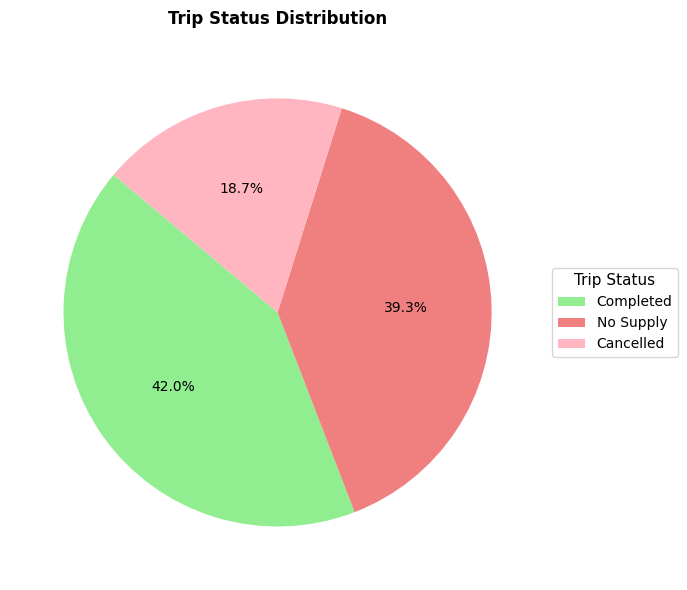

In [20]:
# Plotting the distribution of trip status using a pie chart for visual comparison.

# Count trip statuses
status_counts = df['Trip_Status'].value_counts()
custom_colors = ['lightgreen', 'lightcoral', 'lightpink']

# Set the figure size
plt.figure(figsize=(8, 6))

# Create pie chart
wedges, texts, autotexts = plt.pie(status_counts, autopct='%1.1f%%', startangle=140, colors=custom_colors)

# Title
plt.title('Trip Status Distribution', weight='bold', pad=15)

# Legend
plt.legend(wedges, status_counts.index,
           title="Trip Status",
           loc="center left",
           bbox_to_anchor=(1, 0.5),
           fontsize=10,
           title_fontsize=11)

# Make layout tight
plt.tight_layout()

# Display plot
plt.show()

## Insights

* A pie chart effectively represents the proportional distribution of categorical data, making it ideal to visualize the share of each trip status.
* The chart reveals a notable share of unfulfilled trips, with cancellations and no car availability highlighting a clear supply-demand mismatch despite completed trips being the majority.
* Helps Uber optimize operations, reduce cancellations, boost driver allocation, and enhance customer satisfaction.
* High unfulfilled rates hurt user trust, reduce revenue, frustrate customers, and give competitors an advantage.

#### Count Plot - Ride Requests by Time Slot

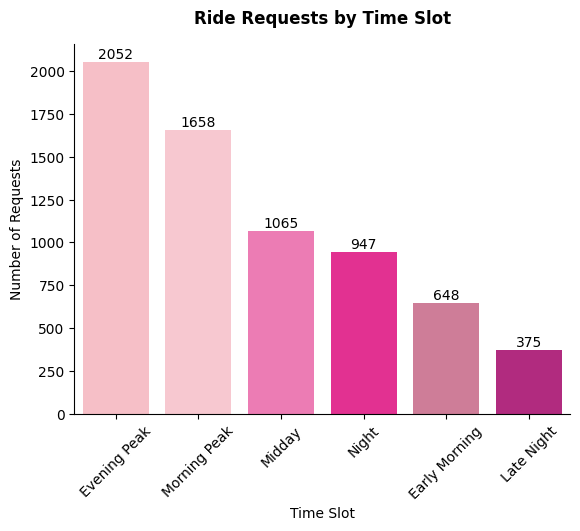

In [21]:
# Visualizing the distribution of ride requests across different time slots
# Create a plot
sns.countplot(data=df,
              x='Time Slot', order=df['Time Slot'].value_counts().index,
              palette=sns.color_palette(['#ffb6c1', '#ffc0cb', '#ff69b4', '#ff1493', '#db7093', '#c71585']))

# Title and Labels
plt.title('Ride Requests by Time Slot', weight='bold', pad=15)
plt.xlabel('Time Slot')
plt.ylabel('Number of Requests')
plt.xticks(rotation=45)
plt.grid(False)
# using despine to remove right and top borders
sns.despine()

# Add data labels on top of each bar
for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width()/2., p.get_height() + 20, int(p.get_height()),
             ha='center')

# Display the plot
plt.show()

## Insights
* A countplot effectively visualizes the volume of ride requests across different time slots, making it easy to identify peak and off-peak demand.
* Ride requests spike during the Morning Peak and Evening Peak, clearly indicating high user demand in these periods.
* Identifying peak time slots helps Uber align driver supply, improve fulfillment, and reduce wait times.
* Low supply during peak demand can cause cancellations or no-car-available issues, hurting user trust and Uber's reputation.

## Histogram - Distribution of Ride Requests by Hour

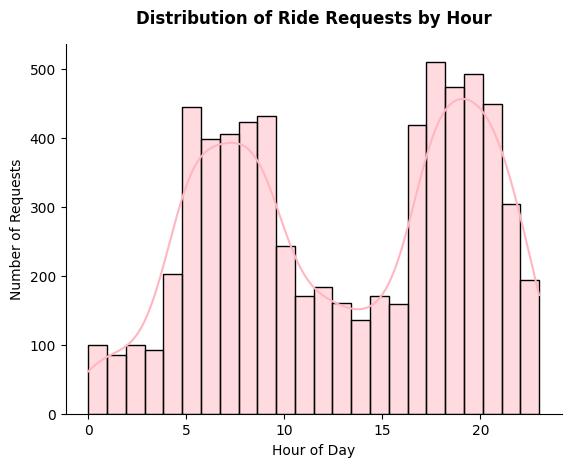

In [22]:
# Visualizing the hourly distribution of ride requests using a histogram

# Create a plot
sns.histplot(df['Request Hour'], bins=24, kde=True, color='#ffb6c1')  # skyblue hex to match theme
plt.title('Distribution of Ride Requests by Hour', weight='bold', pad=15)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Requests')
plt.grid(False)

# removes top and right border for cleaner look
sns.despine()

# Display the plot
plt.show()

#### Insights
* Histogram helps visualize how ride requests are distributed across all 24 hours, highlighting peak activity times.
* Ride requests peak between 7–9 AM and 5–8 PM, while demand drops sharply between 12 AM–4 AM.
* Knowing hourly demand patterns helps Uber deploy drivers more efficiently during high-demand times, improving service availability.
* Low supply during high-demand hours could lead to missed trips, causing frustration and loss of potential revenue.



## Histogram - Distribution of Trip Durations

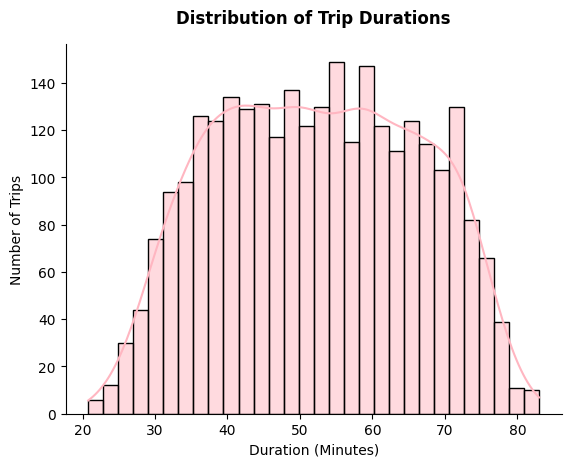

In [23]:
# Plotting distribution of valid trip durations (excluding 'Not Available')

valid_durations = df[df['Trip Duration (Min)'] != 'Not Available']

sns.histplot(valid_durations['Trip Duration (Min)'], bins=30, kde=True, color='#ffb6c1')  # hot pink
plt.title('Distribution of Trip Durations', weight='bold', pad=15)
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Trips')
plt.grid(False)
sns.despine()
plt.show()

#### Insights


*   A histogram is ideal for understanding the spread and frequency of continuous trip durations.
*   Most trips fall between 35 to 65 minutes, with the peak frequency around 50–60 minutes. The distribution is fairly symmetric, with a balanced spread on both sides of the peak.
*   Yes it shows positive impact, it helps Uber optimize pricing and driver assignment based on typical ride lengths.
*   Fewer long trips may indicate cancellations or unavailability, leading to missed high-value ride opportunities for Uber.



## Step Line Plot - Ride Requests Across Weekdays

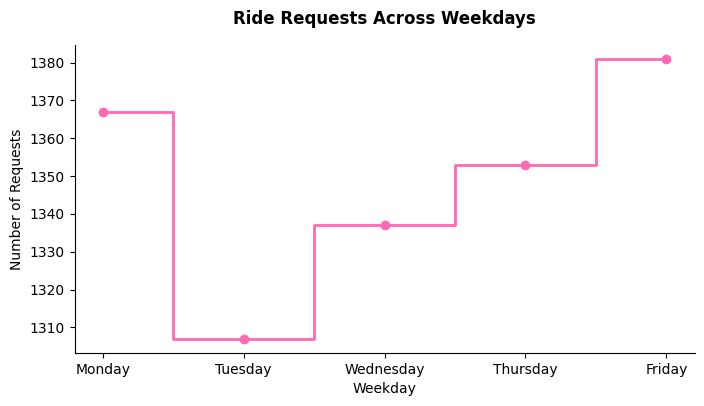

In [24]:
# Count requests per weekday
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
requests_by_day = df['Request Day'].value_counts().reindex(weekday_order)

# Plot step line plot
plt.figure(figsize=(8, 4))
plt.step(requests_by_day.index, requests_by_day.values, where='mid', color='hotpink', linewidth=2, marker='o')

# Title and labels
plt.title('Ride Requests Across Weekdays', weight='bold', pad=15)
plt.xlabel('Weekday')
plt.ylabel('Number of Requests')

# using despine to remove right and top borders
sns.despine()

# Display the plot
plt.show()

#### Insights
*   A step line plot highlights trends across sequential weekdays, helping to detect consistent variations in ride requests.
*   Ride requests steadily increase through the week, peaking sharply on Friday due to pre-weekend demand.
*   Identifying peak weekdays helps Uber optimize driver allocation, reduce wait times, boost fulfillment, and avoid resource oversupply.
*   Low ride volume early in the week may lead to underutilized drivers and lost revenue opportunities.

## Line Plot - Hourly Trend of Ride Requests

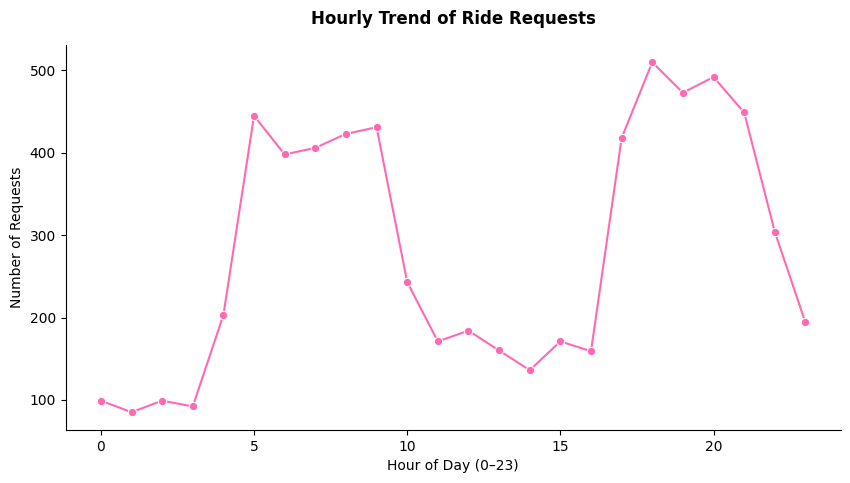

In [25]:
# Plotting a line chart to visualize hourly ride request trends

# Prepare data: count requests for each hour
hourly_requests = df['Request Hour'].value_counts().sort_index()

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_requests.index, y=hourly_requests.values, color='#ff69b4', marker='o')

# Labels and title
plt.title('Hourly Trend of Ride Requests', weight='bold', pad=15)
plt.xlabel('Hour of Day (0–23)')
plt.ylabel('Number of Requests')

# using despine to remove right and top borders
sns.despine()

# Show plot
plt.show()

#### Insights

*   To analyze how ride demand fluctuates by the hour and identify peak request timings.
*   Ride demand spikes sharply at 8–9 AM and 5–8 PM, while it remains low late at night and moderate midday.
*   Yes, aligning driver availability with peak hours helps reduce cancellations and improves fulfillment.
*  Low supply during peak hours may lead to No Supply or Cancelled trips, frustrating users and affecting trust.

## Bi-Variate Analysis

## Stacked Bar Chart - Trip Outcomes by Pickup Location

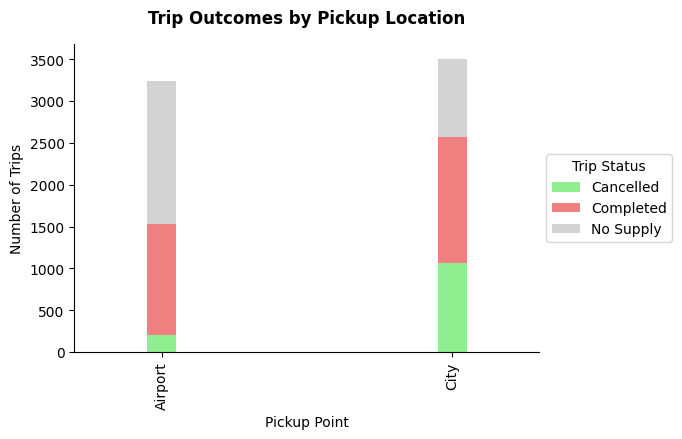

In [26]:
# Visualizing ride statuses across pickup points using a stacked bar chart

# Create a summary table of trip statuses for each pickup point
pickup_status = df.groupby(['Pickup point', 'Trip_Status']).size().unstack().fillna(0)

# Create a plot
ax = pickup_status.plot(kind='bar',
                        stacked=True,
                        color=['lightgreen', 'lightcoral', 'lightgray'],
                        width=0.1,
                        figsize=(6, 4))

# Titles and labels
plt.title('Trip Outcomes by Pickup Location', weight='bold', pad=15)
plt.xlabel('Pickup Point')
plt.ylabel('Number of Trips')
plt.legend(title='Trip Status', loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(False)
# using despine to remove right and top borders
sns.despine()
# Show the plot
plt.show()

#### Insights

* Stacked bar chart clearly shows how trip outcomes vary across pickup points.
* Airport has more unfulfilled trips compared to the city.
* Helps optimize driver allocation by pickup location to reduce service gaps.
* High failure rate at airports may lead to user dissatisfaction and revenue loss.


## Bar Chart - Ride Status by Time Slot

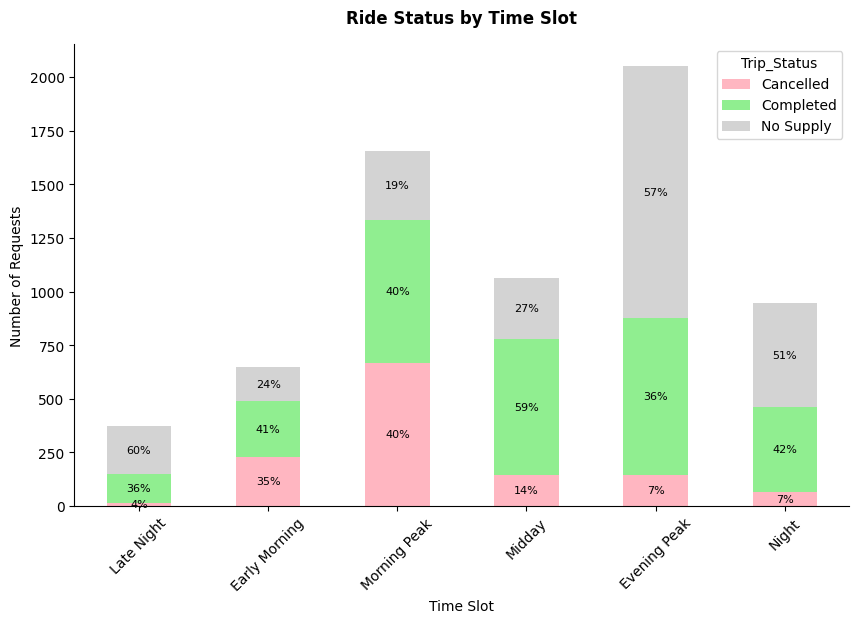

In [27]:
# Plotting a stacked bar chart to visualize the percentage distribution of ride statuses across time slots
fig, ax = plt.subplots(figsize=(10, 6))

custom_colors = {
    'Completed': 'lightgreen',
    'Cancelled': 'lightpink',
    'No Supply': 'lightgrey'
}

# Create a summary table of trip statuses for each time slot
stacked_data = df.groupby(['Time Slot', 'Trip_Status']).size().unstack().fillna(0)

# Reorder time slots for plotting
time_slot_order = ['Late Night', 'Early Morning', 'Morning Peak', 'Midday', 'Evening Peak', 'Night']
stacked_data = stacked_data.reindex(time_slot_order, fill_value=0)

# Create a plot
stacked_data.plot(
    kind='bar',
    stacked=True,
    color=[custom_colors[col] for col in stacked_data.columns],
    ax=ax
)

# Annotating each segment with percentage
for i, time_slot in enumerate(stacked_data.index):
    total = stacked_data.loc[time_slot].sum()
    y_offset = 0
    for status in stacked_data.columns:
        value = stacked_data.loc[time_slot, status]
        if value > 0:
            percent = f"{(value / total * 100):.0f}%"  # Round to nearest whole number
            ax.text(i, y_offset + value / 2, percent, ha='center', va='center', fontsize=8)
            y_offset += value

# Title and lables
plt.title('Ride Status by Time Slot', weight='bold', pad=15)
plt.xlabel('Time Slot')
plt.ylabel('Number of Requests')
plt.xticks(rotation=45)
plt.grid(False)

# using despine to remove right and top borders
sns.despine()

# Display the plot
plt.show()

#### Insights

*   To visualize how ride outcomes (Completed, Cancelled, No Supply) vary across different time slots, highlighting periods of demand-supply mismatch.
*   Evening and Morning Peaks have high ride demand but also high unfulfilled requests due to cancellations and supply issues.
*    understanding time-based service gaps helps Uber deploy drivers more efficiently during critical hours.
*    Yes it leads to negative growth — persistent no-supply cases during peak hours frustrate users, leading to lost revenue and potential customer churn.




## Bar Plot

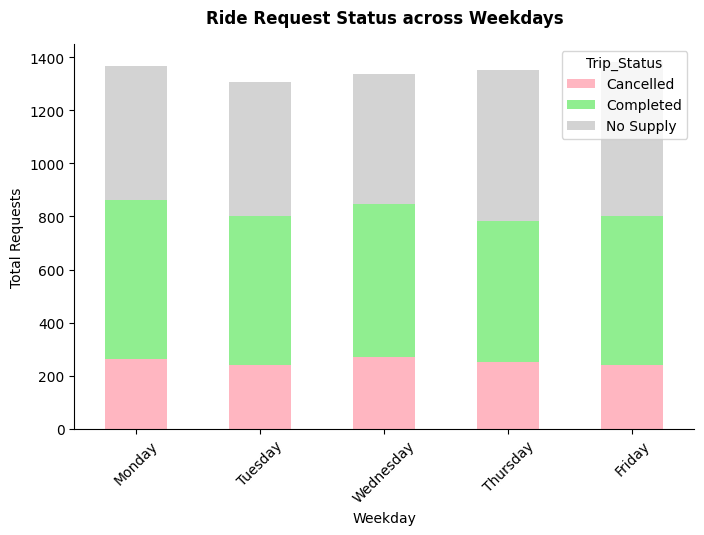

In [28]:
# Plotting Weekday vs Trip Status

# Group by 'Request Day' and 'Trip_Status'
status_counts = df.groupby(['Request Day', 'Trip_Status']).size().unstack(fill_value=0)

# Reorder weekdays
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
status_counts = status_counts.reindex(weekday_order, fill_value=0)

custom_colors = {
    'Completed': 'lightgreen',
    'Cancelled': 'lightpink',
    'No Supply': 'lightgrey'
}
colors_to_use = [custom_colors.get(col, '#333333') for col in status_counts.columns]

# Plot the stacked bar chart
status_counts.plot(kind='bar', stacked=True, figsize=(8, 5), color=colors_to_use)

# Title and labels
plt.title('Ride Request Status across Weekdays', weight='bold', pad=15)
plt.xlabel('Weekday')
plt.ylabel('Total Requests')
plt.xticks(rotation=45)
plt.grid(False)

# using despine to remove right and top borders
sns.despine()

# Display the plot
plt.show()

## Insights


*   Shows all 3 trip statuses across weekdays in one view for easy comparison.
*   No Supply is high on all days; Tuesday–Thursday show more cancellations.
*   Helps plan driver availability better to reduce cancellations and missed trips.
*   High No Supply means lost revenue and unhappy users.



## Line Plot - Hourly Ride Request Trends by Trip Status

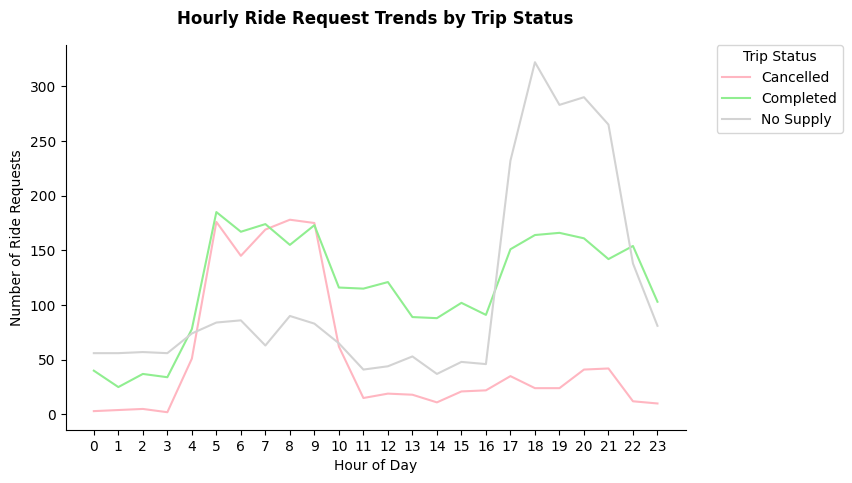

In [29]:
# Plotting Hourly Ride Request Trends by Trip Status using a line plot

# Group by Request Hour and Trip Status, then count requests
hourly_status = df.groupby(['Request Hour', 'Trip_Status']).size().unstack(fill_value=0)

colors = {
    'Completed': 'lightgreen',
    'Cancelled': 'lightpink',
    'No Supply': 'lightgrey'
}

plt.figure(figsize=(8,5))

# Plot each trip status
for status in hourly_status.columns:
    plt.plot(hourly_status.index, hourly_status[status], label=status, color=colors[status])

# Title and labels
plt.title('Hourly Ride Request Trends by Trip Status', weight='bold', pad=15)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Ride Requests')
plt.xticks(range(0, 24)) # Hour ticks from 0 to 23
plt.legend(title='Trip Status', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(False)

# using despine to remove right and top borders
sns.despine()

# Display the plot
plt.show()

## Insights

* Line chart effectively visualizes trends over continuous time (hourly), making it ideal to track changes in trip status across the day.
* Evening hours (5–9 PM) face severe No Supply, while mid-day shows the highest fulfillment rate.
* Yes, understanding hourly disruption patterns enables Uber to deploy drivers strategically, improving fulfillment and customer experience.
* Yes, the driver shortage in evening peaks results in lost revenue and customer churn, directly affecting business performance.



## Stacked Area Plot - Stacked Area Plot of Cancellations by Hour and Weekday

<Figure size 1000x600 with 0 Axes>

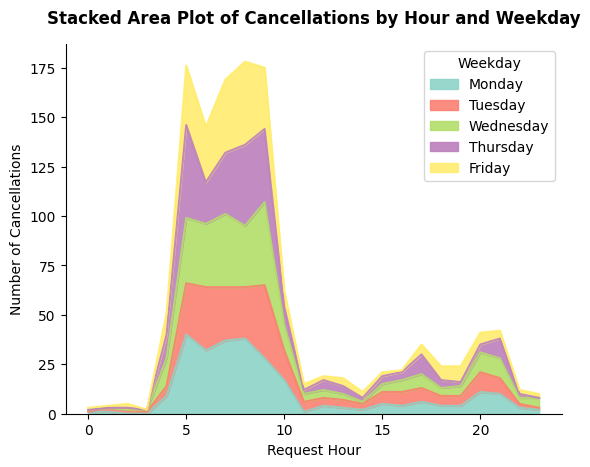

In [30]:
# Visualize how cancellations vary throughout the day and across weekdays.

# Filter only cancelled trips
cancelled = df[df['Trip_Status'] == 'Cancelled']

# Group data: count of cancellations by hour and weekday
cancelled_counts = cancelled.groupby(['Request Hour', 'Request Day']).size().unstack().fillna(0)

# Sort weekdays
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
cancelled_counts = cancelled_counts[weekday_order]

# Plot stacked area chart
plt.figure(figsize=(10, 6))
cancelled_counts.plot.area(colormap='Set3', alpha=0.9)

# Title and labels
plt.title('Stacked Area Plot of Cancellations by Hour and Weekday', weight='bold', pad=15)
plt.xlabel('Request Hour')
plt.ylabel('Number of Cancellations')
plt.legend(title='Weekday', loc='upper right')
plt.grid(False)

# using despine to remove right and top borders
sns.despine()

# Display the plot
plt.show()

#### Insights

*    Stacked area plot helps visualize total cancellations and compare trends across weekdays over hourly time.
*    Cancellations peak sharply around 7–9 AM, with Friday's count almost double compared to other weekdays.
*    Uber can pre-alert drivers for Friday morning rush, improving availability and reducing service gaps.
*    Repeated high cancellations during peak hours may signal driver unavailability or system inefficiencies.



## Scatter Plot - Trip Duration vs Request Hour

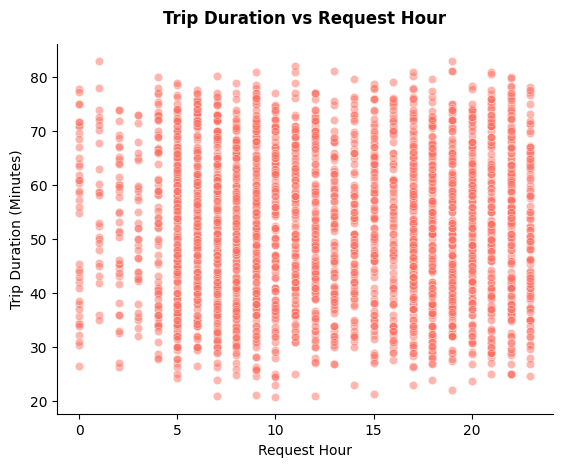

In [31]:
# Scatter plot to analyze how trip duration varies by request hour

# Create a plot
sns.scatterplot(data=df[df['Trip Duration (Min)'].notnull()],
                x='Request Hour',
                y='Trip Duration (Min)',
                alpha=0.5,
                color='#FF6F61')

# Titles and labels
plt.title('Trip Duration vs Request Hour', weight='bold', pad=15)
plt.xlabel('Request Hour')
plt.ylabel('Trip Duration (Minutes)')
plt.grid(False)

# using despine to remove right and top borders
sns.despine()

# Display the plot
plt.show()

#### Insights
-  Scatter plot is ideal to show the distribution and variability of trip durations across each request hour.
- Longer trip durations during early mornings and late evenings suggest increased traffic congestion or a higher number of long-distance airport or office commutes during those hours.
- Understanding duration peaks helps optimize driver allocation and reduce customer wait times during rush hours.
-  High trip durations during peak times may cause delays and reduce trip frequency, impacting service efficiency.




## Heatmap - Request Hour vs Weekday (Completed Trips Only)

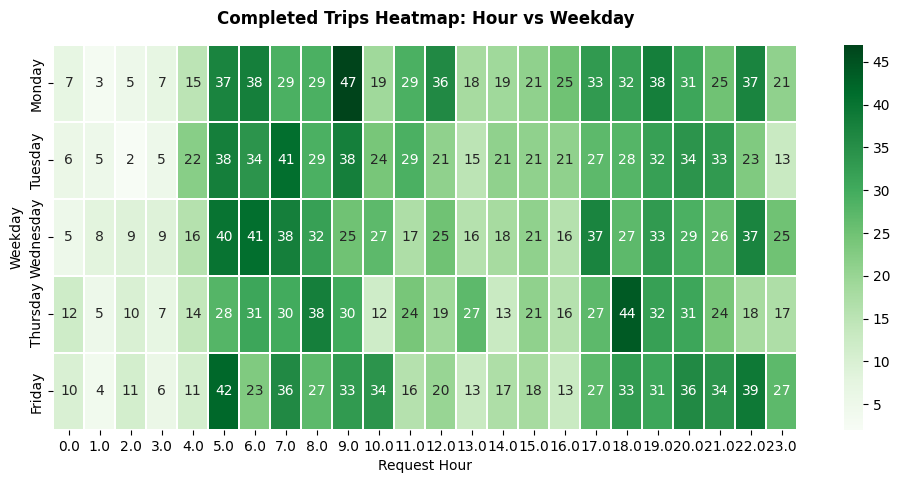

In [32]:
# Prepare hourly completed trip counts by weekday for heatmap visualization
heatmap_data = df[df['Trip_Status'] == 'Completed'] \
    .groupby(['Request Day', 'Request Hour']) \
    .size().unstack().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])

# Set figure size
plt.figure(figsize=(12, 5))

# Create plot
sns.heatmap(heatmap_data, cmap='Greens', linewidths=0.3, annot=True, fmt='g')
plt.title('Completed Trips Heatmap: Hour vs Weekday', weight='bold', pad=15)
plt.xlabel('Request Hour')
plt.ylabel('Weekday')
plt.grid(False)

# Display the Plot
plt.show()

#### Insights

* The heatmap clearly highlights hourly and daily trends in trip completion, making it easy to spot peak and low supply periods visually.
* Peak fulfillment occurs between 5 AM to 10 AM and 5 PM to 8 PM on weekdays, especially Monday and Friday, suggesting strong alignment between driver availability and commuter demand during those hours.
* Optimizing driver allocation during peak hours improves trip fulfillment, reduces wait times, and increases customer retention.
* Low trip completion during late-night hours indicates a supply shortage, leading to missed ride requests and potential customer dissatisfaction.


## Multi-Variate Analysis

#### Chart - 15 - Pair Plot

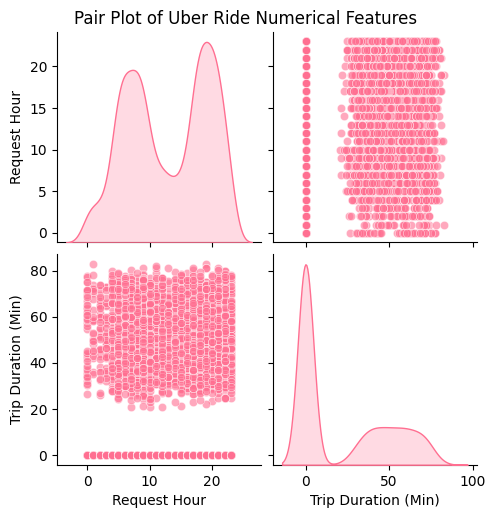

In [33]:
# Filter numerical columns
numeric_cols = ['Request Hour', 'Drop Hour', 'Trip Duration (Min)']

# Optional: Remove nulls and fill 0 if necessary
df[numeric_cols] = df[numeric_cols].fillna(0)

# Plot with pinkish color theme
sns.pairplot(
    df[numeric_cols],
    diag_kind='kde',
    plot_kws={'color': '#FF6F91', 'alpha': 0.6},
    diag_kws={'shade': True, 'color': '#FF6F91'}
)

# Title
plt.suptitle('Pair Plot of Uber Ride Numerical Features ', y=1.02)
plt.show()

## Insights

*   Pair plot helps explore relationships between numeric variables like hours and trip duration.
*   Longer trips are slightly more common in early mornings and evenings; moderate spread in all combinations.
*   Supports identification of time windows that consistently yield longer trips, aiding route optimization.
*   No strong clustering may indicate inefficiencies or random driver assignment affecting consistency.



## **Actionable Strategy for Growth**

To bridge the demand-supply gap, Uber should align driver availability with peak hours (especially mornings and evenings) using incentives and predictive dispatching. High midweek cancellations call for better driver engagement and shift management. Trip duration trends suggest route optimization is key to improving trip efficiency. Publishing fulfillment metrics and promoting reliable service can build user trust. These data-backed strategies will enhance ride completion rates, reduce cancellations, and drive sustainable growth.

# **Conclusion**

- **Peak Hour Gaps:** Most ride failures (especially *No Supply*) occur during 7–9 AM and 5–9 PM, indicating a critical mismatch between rider demand and driver availability.

- **Friday Morning Woes:** Cancellations spike drastically on Friday mornings, suggesting a need for stronger driver incentives or better route planning on peak weekdays.

- **Duration Trends:** Long-duration trips are more common in early mornings and late evenings — possibly due to airport/office commutes or heavier traffic congestion.

- **Heatmap Signals:** Highest ride fulfillment happens during morning and evening hours on weekdays, while late-night hours consistently show poor service coverage.

- **No Strong Clustering:** Pair plot reveals moderate spread across numerical features, indicating irregular trip patterns and possibly inefficient driver allocation.
